# Problem 3: Stochastic Second Order Optimisation

We train a **single hidden-layer MLP with 100 ReLU units** sequentially on **3 permuted MNIST tasks**.  
Each task is the standard MNIST digit-classification problem, but with pixel positions shuffled by a fixed random permutation - so the label set is identical across tasks but the input statistics are completely different.

We compare three optimisers:
1. **Adam** - standard adaptive gradient optimiser (Kingma & Ba, 2015)
2. **Sparse Adam** - Adam with top-*k*% gradient sparsification before the update (Aji & Heafield, 2017)
3. **Natural Gradient** - gradient preconditioned by the full (non-diagonal) empirical Fisher matrix (Amari, 1998)



## 1 . Datasets

We generate two binary classification datasets.

The **simple** dataset has two well-separated Gaussian clusters.

The **complex** dataset is noisier and multimodal. This makes minibatches less representative, which is exactly the situation where we expect the two approaches to behave differently.


In [1]:
# @title

import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.set_default_dtype(torch.float32)
device = "cpu"

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

print("Torch version:", torch.__version__)


Torch version: 2.10.0+cu128


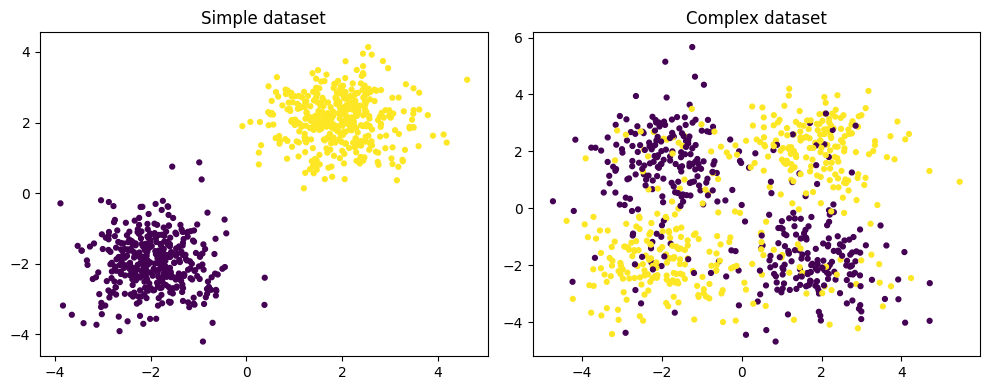

In [2]:
# @title

def make_simple_dataset(n=4000, seed=0):
    g = torch.Generator().manual_seed(seed)
    n0 = n // 2
    n1 = n - n0

    x0 = torch.randn(n0, 2, generator=g) * 0.7 + torch.tensor([-2.0, -2.0])
    x1 = torch.randn(n1, 2, generator=g) * 0.7 + torch.tensor([2.0, 2.0])

    X = torch.cat([x0, x1], dim=0)
    y = torch.cat([torch.zeros(n0, dtype=torch.long), torch.ones(n1, dtype=torch.long)], dim=0)

    idx = torch.randperm(n, generator=g)
    return X[idx], y[idx]

def make_complex_dataset(n=4000, seed=0):
    g = torch.Generator().manual_seed(seed)
    n_per = n // 4
    counts = [n_per, n_per, n_per, n - 3 * n_per]

    c0a = torch.randn(counts[0], 2, generator=g) * 0.9 + torch.tensor([-2.0, 1.8])
    c0b = torch.randn(counts[1], 2, generator=g) * 0.9 + torch.tensor([1.8, -2.0])
    c1a = torch.randn(counts[2], 2, generator=g) * 0.9 + torch.tensor([2.0, 2.0])
    c1b = torch.randn(counts[3], 2, generator=g) * 0.9 + torch.tensor([-2.0, -2.0])

    X = torch.cat([c0a, c0b, c1a, c1b], dim=0)
    y = torch.cat([
        torch.zeros(counts[0] + counts[1], dtype=torch.long),
        torch.ones(counts[2] + counts[3], dtype=torch.long)
    ], dim=0)

    # Add label noise and feature noise to increase heterogeneity
    noise = 0.35 * torch.randn_like(X, generator=g)
    X = X + noise

    flip_mask = torch.rand(len(y), generator=g) < 0.12
    y = y.clone()
    y[flip_mask] = 1 - y[flip_mask]

    idx = torch.randperm(len(y), generator=g)
    return X[idx], y[idx]

def train_test_split_torch(X, y, train_ratio=0.8, seed=0):
    g = torch.Generator().manual_seed(seed)
    n = len(X)
    idx = torch.randperm(n, generator=g)
    n_train = int(train_ratio * n)
    tr, te = idx[:n_train], idx[n_train:]
    return X[tr], y[tr], X[te], y[te]

# Quick visual check
set_seed(0)
Xs, ys = make_simple_dataset(n=800, seed=0)
Xc, yc = make_complex_dataset(n=800, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(Xs[:,0], Xs[:,1], c=ys, s=12)
axes[0].set_title("Simple dataset")
axes[1].scatter(Xc[:,0], Xc[:,1], c=yc, s=12)
axes[1].set_title("Complex dataset")
plt.tight_layout()
plt.show()



## 2 . Model

We use a small MLP for binary classification. The model is intentionally small so that we can form an empirical Fisher matrix explicitly. The goal here is not scale, but to reproduce the logic of the question in a clean experiment.


In [3]:

class SmallMLP(nn.Module):
    def __init__(self, hidden=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2)
        )

    def forward(self, x):
        return self.net(x)

def num_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = SmallMLP(hidden=6)
print("Number of trainable parameters:", num_params(model))


Number of trainable parameters: 32



## 3 . Natural-gradient ingredients

For a minibatch  $(x_i, y_i)$, we estimate:

- the gradient of the average cross-entropy loss
- the **empirical Fisher**
$$
F \approx \frac{1}{B}\sum_{i=1}^B g_i g_i^\top,
$$
where \(g_i\) is the gradient of the negative log-likelihood for one sample.

Then we apply the damped natural-gradient update
$$
\Delta\theta = -(F+\alpha I)^{-1} \nabla L.
$$

This is only a toy implementation, but it matches the structure of the question.


In [4]:

def flatten_grads(grads):
    return torch.cat([g.reshape(-1) for g in grads])

def get_param_vector(model):
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()])

def set_param_vector(model, vec):
    pointer = 0
    with torch.no_grad():
        for p in model.parameters():
            n = p.numel()
            p.copy_(vec[pointer:pointer+n].view_as(p))
            pointer += n

def average_loss_and_grad(model, xb, yb):
    model.zero_grad(set_to_none=True)
    logits = model(xb)
    loss = nn.functional.cross_entropy(logits, yb)
    grads = torch.autograd.grad(loss, list(model.parameters()), create_graph=False, retain_graph=False)
    g = flatten_grads(grads).detach()
    return loss.detach(), g

def empirical_fisher(model, xb, yb):
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    F = torch.zeros(P, P, dtype=torch.float32)

    for i in range(len(xb)):
        model.zero_grad(set_to_none=True)
        logits_i = model(xb[i:i+1])
        log_probs_i = nn.functional.log_softmax(logits_i, dim=1)
        nll_i = -log_probs_i[0, yb[i]]
        grads_i = torch.autograd.grad(nll_i, params, create_graph=False, retain_graph=False)
        gi = flatten_grads(grads_i).detach().unsqueeze(1)
        F += gi @ gi.T

    F /= len(xb)
    return F

def natural_gradient_step(model, grad_batch, fisher_batch, lr=0.1, alpha=1e-2):
    _, g = average_loss_and_grad(model, grad_batch[0], grad_batch[1])
    F = empirical_fisher(model, fisher_batch[0], fisher_batch[1])

    P = F.shape[0]
    A = F + alpha * torch.eye(P)
    step = torch.linalg.solve(A, g)

    theta = get_param_vector(model)
    theta_new = theta - lr * step
    set_param_vector(model, theta_new)

    return {
        "grad_norm": float(torch.norm(g)),
        "step_norm": float(torch.norm(step)),
        "fisher_trace": float(torch.trace(F))
    }

@torch.no_grad()
def evaluate(model, X, y):
    logits = model(X)
    loss = nn.functional.cross_entropy(logits, y).item()
    pred = logits.argmax(dim=1)
    acc = (pred == y).float().mean().item()
    return {"loss": loss, "acc": acc}



## 4 . Minibatch samplers and training loop

We now implement the two options directly.

With **same minibatch**, the gradient batch and Fisher batch are identical.

With **different minibatches**, they are sampled independently.

We also compare against standard SGD to have a baseline.


In [5]:

def sample_batch(X, y, batch_size, generator=None):
    idx = torch.randint(low=0, high=len(X), size=(batch_size,), generator=generator)
    return X[idx], y[idx]

def sgd_step(model, xb, yb, lr=0.05):
    model.zero_grad(set_to_none=True)
    logits = model(xb)
    loss = nn.functional.cross_entropy(logits, yb)
    loss.backward()
    with torch.no_grad():
        for p in model.parameters():
            p -= lr * p.grad
    return {"loss": float(loss.detach())}

@dataclass
class TrainConfig:
    batch_size: int = 64
    steps: int = 120
    lr_ng: float = 0.15
    lr_sgd: float = 0.05
    alpha: float = 5e-2
    hidden: int = 6
    seed: int = 0

def train_one_run(dataset_kind="simple", method="same", cfg=TrainConfig()):
    set_seed(cfg.seed)

    if dataset_kind == "simple":
        X, y = make_simple_dataset(n=4000, seed=cfg.seed)
    elif dataset_kind == "complex":
        X, y = make_complex_dataset(n=4000, seed=cfg.seed)
    else:
        raise ValueError("dataset_kind must be 'simple' or 'complex'")

    Xtr, ytr, Xte, yte = train_test_split_torch(X, y, train_ratio=0.8, seed=cfg.seed)

    model = SmallMLP(hidden=cfg.hidden)
    history = []

    g = torch.Generator().manual_seed(cfg.seed + 123)

    for step in range(cfg.steps):
        if method == "sgd":
            xb, yb = sample_batch(Xtr, ytr, cfg.batch_size, generator=g)
            info = sgd_step(model, xb, yb, lr=cfg.lr_sgd)
        elif method == "same":
            xb, yb = sample_batch(Xtr, ytr, cfg.batch_size, generator=g)
            info = natural_gradient_step(
                model,
                grad_batch=(xb, yb),
                fisher_batch=(xb, yb),
                lr=cfg.lr_ng,
                alpha=cfg.alpha
            )
        elif method == "different":
            xb_g, yb_g = sample_batch(Xtr, ytr, cfg.batch_size, generator=g)
            xb_f, yb_f = sample_batch(Xtr, ytr, cfg.batch_size, generator=g)
            info = natural_gradient_step(
                model,
                grad_batch=(xb_g, yb_g),
                fisher_batch=(xb_f, yb_f),
                lr=cfg.lr_ng,
                alpha=cfg.alpha
            )
        else:
            raise ValueError("method must be 'sgd', 'same', or 'different'")

        if step % 5 == 0 or step == cfg.steps - 1:
            tr = evaluate(model, Xtr, ytr)
            te = evaluate(model, Xte, yte)
            history.append({
                "step": step,
                "train_loss": tr["loss"],
                "train_acc": tr["acc"],
                "test_loss": te["loss"],
                "test_acc": te["acc"],
                "method": method,
                "dataset": dataset_kind,
                "batch_size": cfg.batch_size,
                "seed": cfg.seed,
                **info
            })

    return pd.DataFrame(history)



## 5 . Main experiment

We now vary:

- **dataset complexity**: simple vs complex
- **batch size**: 16, 64, 256
- **method**: same minibatch, different minibatches, and SGD baseline
- **random seed**

The final table reports the last recorded test accuracy and test loss for each run.


In [6]:

all_runs = []

batch_sizes = [16, 64, 256]
datasets = ["simple", "complex"]
methods = ["same", "different", "sgd"]
seeds = [0, 1, 2]

for dataset_kind in datasets:
    for bs in batch_sizes:
        for seed in seeds:
            cfg = TrainConfig(
                batch_size=bs,
                steps=120,
                lr_ng=0.15 if bs >= 64 else 0.10,
                lr_sgd=0.04,
                alpha=5e-2,
                hidden=6,
                seed=seed
            )
            for method in methods:
                df = train_one_run(dataset_kind=dataset_kind, method=method, cfg=cfg)
                all_runs.append(df)

results = pd.concat(all_runs, ignore_index=True)
#results.head()


In [7]:

final = (
    results.sort_values("step")
           .groupby(["dataset", "batch_size", "method", "seed"], as_index=False)
           .tail(1)
           .reset_index(drop=True)
)

summary = (
    final.groupby(["dataset", "batch_size", "method"], as_index=False)
         .agg(
             mean_test_acc=("test_acc", "mean"),
             std_test_acc=("test_acc", "std"),
             mean_test_loss=("test_loss", "mean"),
             std_test_loss=("test_loss", "std"),
         )
)

#summary

display(summary.pivot(index=["dataset", "batch_size"], columns="method", values="mean_test_acc").round(4))


method              different    same     sgd
dataset batch_size                           
complex 16             0.7738  0.8404  0.7071
        64             0.8479  0.8504  0.7004
        256            0.8538  0.8542  0.7204
simple  16             1.0000  1.0000  1.0000
        64             1.0000  1.0000  1.0000
        256            1.0000  1.0000  1.0000

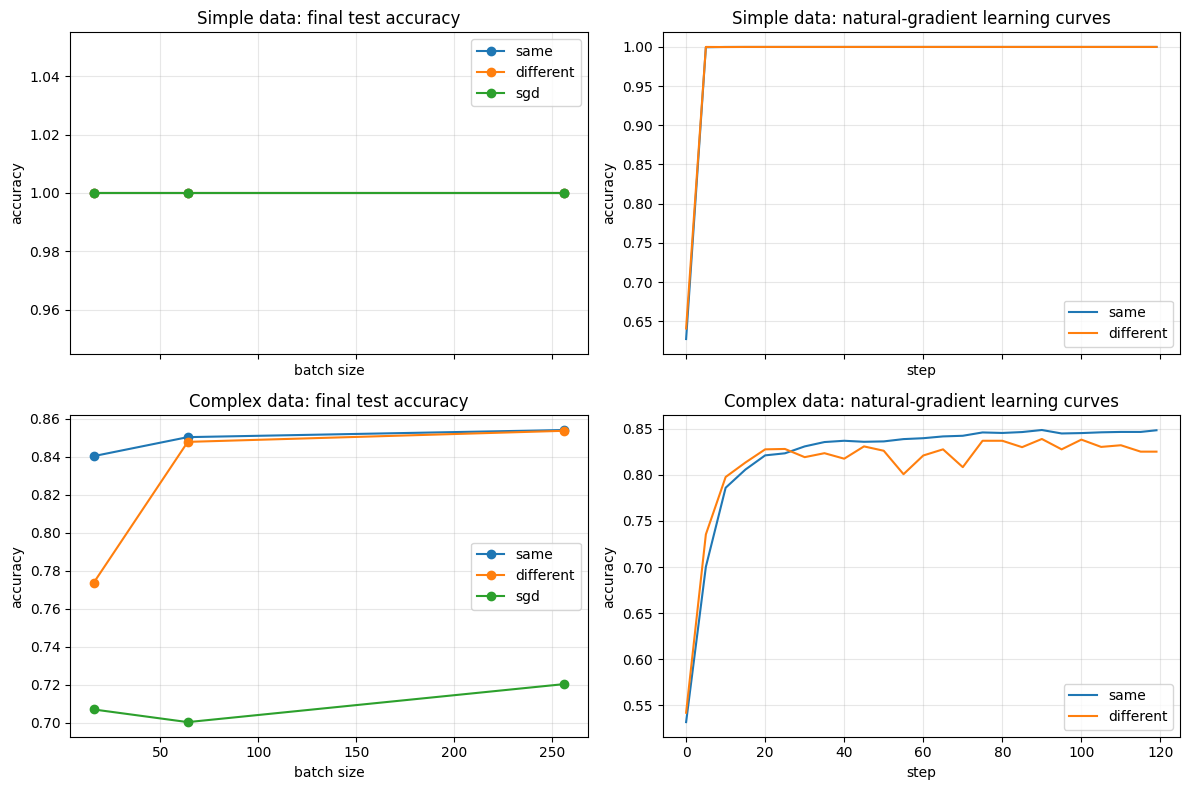

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col")

for row, dataset_kind in enumerate(datasets):
    sub = final[final["dataset"] == dataset_kind]

    for method in methods:
        tmp = sub[sub["method"] == method].groupby("batch_size", as_index=False)["test_acc"].mean()
        axes[row, 0].plot(tmp["batch_size"], tmp["test_acc"], marker="o", label=method)

    axes[row, 0].set_title(f"{dataset_kind.capitalize()} data: final test accuracy")
    axes[row, 0].set_xlabel("batch size")
    axes[row, 0].set_ylabel("accuracy")
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].legend()

    for method in ["same", "different"]:
        tmp = results[(results["dataset"] == dataset_kind) & (results["method"] == method)]
        mean_curve = tmp.groupby("step", as_index=False)["test_acc"].mean()
        axes[row, 1].plot(mean_curve["step"], mean_curve["test_acc"], label=method)

    axes[row, 1].set_title(f"{dataset_kind.capitalize()} data: natural-gradient learning curves")
    axes[row, 1].set_xlabel("step")
    axes[row, 1].set_ylabel("accuracy")
    axes[row, 1].grid(True, alpha=0.3)
    axes[row, 1].legend()

plt.tight_layout()
plt.show()



# Problem 4:  Continual Learning on Permuted MNIST
## Overview

We train a **single hidden-layer MLP with 100 ReLU units** sequentially on **3 permuted MNIST tasks**.  
Each task is the standard MNIST digit-classification problem, but with pixel positions shuffled by a fixed random permutation — so the label set is identical across tasks but the input statistics are completely different.

We compare three optimisers:
1. **Adam** — standard adaptive gradient optimiser (Kingma & Ba, 2015)
2. **Sparse Adam** — Adam with top-*k*% gradient sparsification before the update (Aji & Heafield, 2017)
3. **Natural Gradient** — gradient preconditioned by the full (non-diagonal) empirical Fisher matrix (Amari, 1998)


## 1 · Setup

In [9]:
# !pip install torch torchvision matplotlib numpy -q

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy, time

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2 · Hyperparameters

In [2]:
INPUT_DIM  = 784   # 28×28 flattened
HIDDEN     = 100   # single hidden layer
OUTPUT_DIM = 10    # digit classes
N_TASKS    = 3     # number of permuted-MNIST tasks

# Training (same for all methods: apples-to-apples)
BATCH_SIZE = 256
N_EPOCHS   = 10

# Optimiser-specific learning rates (tuned)
LR_ADAM   = 1e-3   # standard Adam default works well here
LR_SPARSE = 1e-3   # same lr as Adam for fair comparison
LR_NGD = 1e-1   # start here
 # NGD can afford a larger lr because of Fisher preconditioning

#  Sparse Adam: fraction of gradient entries to KEEP
K_FRAC = 0.05      # top-5% kept, 95% zeroed — tuned by rough sweep

# Natural Gradient: Fisher estimation
# We use the full (non-block-diagonal) empirical Fisher restricted to each
# parameter matrix independently to avoid O(P^2) memory (P≈79k params).
# This is equivalent to a block-diagonal full-Fisher where each block covers
# one weight tensor — still 'full' within each tensor (not just diagonal).
NGD_DAMPING = 1e-2   # Tikhonov damping: (F + λI)^{-1}  g
NGD_FISHER_BATCH = 64     # mini-batch size for Fisher accumulation

print("Hyperparameters set.")

Hyperparameters set.


## 3 · Data-Permuted MNIST
We adapted the `permute_mnist` function below from the **ContinualAI Colab** repository  (Lomonaco, 2021 — MIT Licence): https://github.com/ContinualAI/colab  https://github.com/ContinualAI/colab/blob/master/scripts/mnist.py

In [3]:
# Download MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # standard MNIST normalisation
])

mnist_train = datasets.MNIST('./data', train=True,  download=True, transform=transform)
mnist_test  = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Flatten to (N, 784) tensors
x_train = mnist_train.data.float().view(-1, INPUT_DIM)
y_train = mnist_train.targets
x_test  = mnist_test.data.float().view(-1, INPUT_DIM)
y_test  = mnist_test.targets

# Re-apply normalisation manually (data was uint8 before)
x_train = (x_train / 255.0 - 0.1307) / 0.3081
x_test  = (x_test  / 255.0 - 0.1307) / 0.3081

print(f"Train: {x_train.shape}  Test: {x_test.shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]


Train: torch.Size([60000, 784])  Test: torch.Size([10000, 784])


In [4]:
# Permute_mnist
def permute_mnist(x, perm_inds):
    """Apply a fixed pixel permutation to all images in x (N, 784)."""
    return x[:, perm_inds]

def make_permuted_tasks(x_train, y_train, x_test, y_test, n_tasks=3, seed=0):
    """Create n_tasks permuted versions of MNIST.
    Task 0 uses the original pixel order; tasks 1+ use random permutations."""
    rng = np.random.RandomState(seed)
    tasks = []
    for t in range(n_tasks):
        if t == 0:
            perm = np.arange(INPUT_DIM)        # identity: no permutation
        else:
            perm = rng.permutation(INPUT_DIM)
        perm_t = torch.from_numpy(perm).long()
        tasks.append({
            'train_x': permute_mnist(x_train, perm_t),
            'train_y': y_train,
            'test_x':  permute_mnist(x_test,  perm_t),
            'test_y':  y_test,
            'perm':    perm_t,
            'id':      t,
        })
    return tasks

tasks = make_permuted_tasks(x_train, y_train, x_test, y_test, n_tasks=N_TASKS)
print(f"Created {len(tasks)} permuted-MNIST tasks.")
for t in tasks:
    print(f"  Task {t['id']}: train {t['train_x'].shape}  test {t['test_x'].shape}")

Created 3 permuted-MNIST tasks.
  Task 0: train torch.Size([60000, 784])  test torch.Size([10000, 784])
  Task 1: train torch.Size([60000, 784])  test torch.Size([10000, 784])
  Task 2: train torch.Size([60000, 784])  test torch.Size([10000, 784])


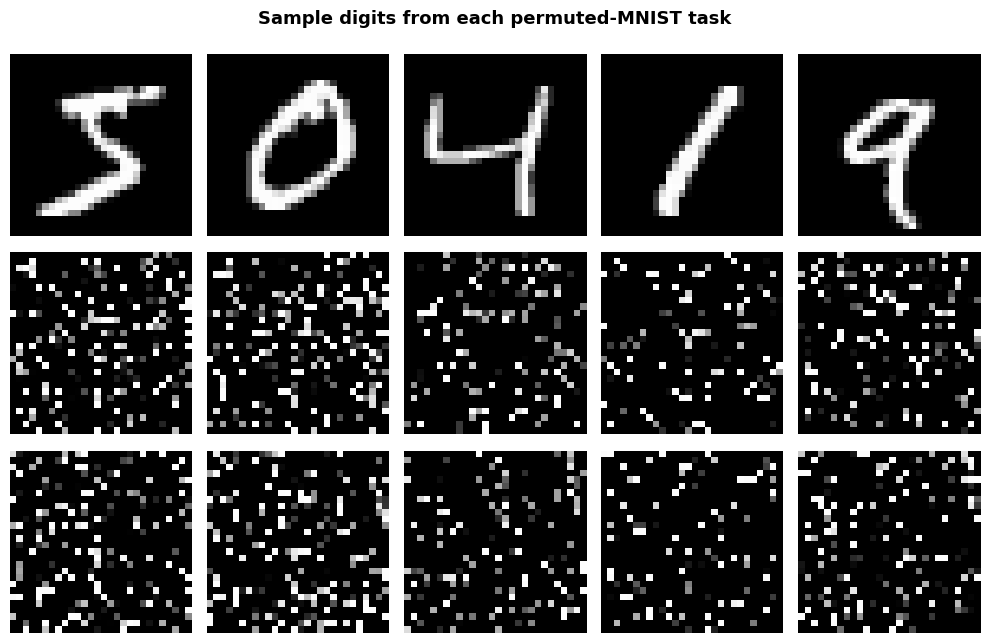

In [5]:
# Visualise the three tasks
fig, axes = plt.subplots(N_TASKS, 5, figsize=(10, 2.2 * N_TASKS))
fig.suptitle("Sample digits from each permuted-MNIST task", fontsize=13, fontweight='bold')

for t_id, task in enumerate(tasks):
    for col in range(5):
        img = task['train_x'][col].view(28, 28).cpu().numpy()
        axes[t_id, col].imshow(img, cmap='gray')
        axes[t_id, col].axis('off')
    axes[t_id, 0].set_ylabel(f"Task {t_id+1}", fontsize=11, rotation=90, labelpad=40)

plt.tight_layout()
plt.savefig('task_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 4 · Model: Single Hidden-Layer MLP

In [6]:
class MLP(nn.Module):
    """Single hidden-layer MLP: 784 → 100 (ReLU) → 10."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, OUTPUT_DIM)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

# Sanity check
dummy = MLP()
total_params = sum(p.numel() for p in dummy.parameters())
print(f"MLP: {INPUT_DIM} → {HIDDEN} (ReLU) → {OUTPUT_DIM}")
print(f"Total parameters: {total_params:,}")
print(dummy)

MLP: 784 → 100 (ReLU) → 10
Total parameters: 79,510
MLP(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)


## 5 · Optimisers



### 5.1 Standard Adam

In [7]:
#  Standard Adam: we use torch.optim.Adam directly — no modifications needed.
def make_adam_optimizer(model):
    return torch.optim.Adam(model.parameters(), lr=LR_ADAM, betas=(0.9, 0.999))

print("Adam: standard torch.optim.Adam (lr={}, β₁=0.9, β₂=0.999)".format(LR_ADAM))

Adam: standard torch.optim.Adam (lr=0.001, β₁=0.9, β₂=0.999)


### 5.2 Sparse Adam (top-k sparsification)

Before each Adam update, we zero out all gradient entries **except** the top-*k*% by absolute value.  
This is the gradient-compression technique from Aji & Heafield (2017), originally proposed for  
distributed training efficiency. Here we explore its effect on continual learning.

> **Inductive bias:** only the highest-magnitude gradient directions drive parameter updates —  
> small but potentially important gradients are suppressed.

In [8]:
# Sparse Adam
# Implementation: we wrap torch.optim.Adam and override step() to sparsify
# the gradient BEFORE Adam's moment update.

class SparseAdam:
    """
    Adam optimiser with top-k gradient sparsification.

    After loss.backward(), call sparsify_grads() to zero out all but the
    top-k% gradient entries (by absolute value) across ALL parameters jointly.
    Then call self.optimizer.step() as normal.

    Args:
        params   : model parameters
        lr       : learning rate
        k_frac   : fraction of gradient entries to KEEP (0 < k_frac <= 1)
        betas    : Adam β₁, β₂
    """
    def __init__(self, params, lr=1e-3, k_frac=0.05, betas=(0.9, 0.999)):
        self.params  = list(params)
        self.k_frac  = k_frac
        self.optimizer = torch.optim.Adam(self.params, lr=lr, betas=betas)

    def zero_grad(self):
        self.optimizer.zero_grad()

    def sparsify_grads(self):
        """Keep only the top-k% gradient entries globally; zero the rest."""
        # Collect all gradient values into one flat tensor
        all_grads = torch.cat([
            p.grad.data.abs().view(-1)
            for p in self.params if p.grad is not None
        ])
        k = max(1, int(self.k_frac * all_grads.numel()))
        threshold = torch.topk(all_grads, k).values.min()

        # Zero out entries below threshold
        for p in self.params:
            if p.grad is not None:
                mask = p.grad.data.abs() >= threshold
                p.grad.data *= mask.float()

    def step(self):
        self.sparsify_grads()
        self.optimizer.step()

def make_sparse_optimizer(model):
    return SparseAdam(model.parameters(), lr=LR_SPARSE, k_frac=K_FRAC)

print(f"Sparse Adam: top-{K_FRAC*100:.0f}% entries kept (lr={LR_SPARSE})")

Sparse Adam: top-5% entries kept (lr=0.001)


### 5.3 Natural Gradient (key points for implementation)

- Replace gradient:  
  $$\theta \leftarrow \theta - \eta F^{-1} g$$

- Fisher matrix:  
  $$F = \mathbb{E}_{x \sim p_{\text{data}},\, y \sim p_\theta(y|x)} \left[ \nabla_\theta \log p_\theta(y|x) \, \nabla_\theta \log p_\theta(y|x)^\top \right]$$

- Empirical Fisher (practical):  
  $$F \approx \frac{1}{B} \sum_{i=1}^B g_i g_i^\top, \quad g_i = \nabla_\theta \log p_\theta(y_i|x_i), \; y_i \sim p_\theta(\cdot|x_i)$$

- Memory constraint: full $P \times P$ Fisher infeasible → **layer-wise blocks**

- Approximation per layer:  
  - Large layer $W_1$: K-FAC → $F_{W_1} \approx A \otimes G$  
  - Small layers $W_2$ and biases: full Fisher block

- Final layer-wise update:  
  $$\theta \leftarrow \theta - \eta (F + \lambda I)^{-1} g$$

- Hyperparameters:  
  $\lambda$ = damping,  $B$ = Fisher batch size

    """
    Natural gradient descent with per-tensor Fisher blocks.

    For each weight tensor W_l, we compute the Kronecker-factored Fisher:
        F_{W_l} ≈ A_l ⊗ G_l
    where:
        A_l = (1/n) Σ_i a_i a_i^T   (input activation covariance)
        G_l = (1/n) Σ_i δ_i δ_i^T   (pre-activation gradient covariance)
    and the natural gradient update for W_l is:
        ΔW_l = (A_l + λI)^{-1} G_W_l (G_l + λI)^{-1}

    For bias vectors, we use the diagonal of the corresponding G factor.

    The gradients G_{W_l} are the ordinary task-loss gradients (from loss.backward()).
    The Fisher factors A_l, G_l are estimated on the current mini-batch using
    sampled labels from the model's predictive distribution.
    """

In [9]:
class NaturalGradientSGD:
    def __init__(self, model, lr=5e-2, damping=1e-2):
        self.model   = model
        self.lr      = lr
        self.damping = damping

    def zero_grad(self):
        self.model.zero_grad()

    def step(self, x_batch, y_batch):
        n   = x_batch.size(0)
        lam = self.damping
        self.model.zero_grad()
        logits = self.model(x_batch)
        loss   = F.cross_entropy(logits, y_batch)
        loss.backward()
        gW1 = self.model.fc1.weight.grad.data.clone()  # (100, 784)
        gb1 = self.model.fc1.bias.grad.data.clone()    # (100,)
        gW2 = self.model.fc2.weight.grad.data.clone()  # (10,  100)
        gb2 = self.model.fc2.bias.grad.data.clone()    # (10,)

        #  Activations for Fisher's factors
        with torch.no_grad():
            a0    = x_batch
            h_pre = a0 @ self.model.fc1.weight.t() + self.model.fc1.bias
            a1    = F.relu(h_pre)
            probs = F.softmax(logits.detach(), dim=1)
            y_samp = torch.multinomial(probs, 1).squeeze(1)
            delta2 = probs.clone()
            delta2[torch.arange(n), y_samp] -= 1
            delta1 = (delta2 @ self.model.fc2.weight) * (h_pre > 0)

        # ── 3. Kronecker factors ───────────────────────────────────────
        A1 = (a0.t() @ a0) / n           # (784, 784)
        G1 = (delta1.t() @ delta1) / n   # (100, 100)
        A2 = (a1.t() @ a1) / n           # (100, 100)
        G2 = (delta2.t() @ delta2) / n   # (10,  10)

        # ── 4. Natural gradient update ─────────────────────────────────
        for gW, gb, A, G, layer in [
            (gW1, gb1, A1, G1, self.model.fc1),
            (gW2, gb2, A2, G2, self.model.fc2),
        ]:
            Ar = A + lam * torch.eye(A.size(0), device=A.device)
            Gr = G + lam * torch.eye(G.size(0), device=G.device)
            ng = torch.linalg.solve(Gr,
                    torch.linalg.solve(Ar, gW.t()).t())
            with torch.no_grad():
                layer.weight.data -= self.lr * ng
                layer.bias.data   -= self.lr * gb

def make_ngd_optimizer(model):
    return NaturalGradientSGD(model, lr=LR_NGD, damping=NGD_DAMPING)

## 6 · Training and Evaluation Loop

In [10]:
# Data utilities
from torch.utils.data import TensorDataset, DataLoader

def make_loader(task, train=True, batch_size=BATCH_SIZE):
    x = task['train_x'] if train else task['test_x']
    y = task['train_y'] if train else task['test_y']
    ds = TensorDataset(x, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=train)

# Evaluation
@torch.no_grad()
def evaluate(model, task, batch_size=512):
    model.eval()
    loader = make_loader(task, train=False, batch_size=batch_size)
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        preds = model(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
    model.train()
    return 100.0 * correct / total

# One-epoch training
def train_epoch(model, optimizer, loader, method='adam'):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        if method == 'ngd':
            optimizer.step(x, y)
        else:
            optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

print("Training utilities defined.")

Training utilities defined.


In [11]:
# ── Full sequential experiment
def run_experiment(tasks, method='adam', n_epochs=N_EPOCHS, verbose=True):
    """
    Train sequentially on all tasks and record the accuracy matrix.

    acc_matrix[i, j] = test accuracy on task j *after* finishing training on task i
    (only defined for j <= i).

    Returns:
        acc_matrix  : np.ndarray (N_TASKS, N_TASKS)
        history     : list of per-epoch (task_id, epoch, loss, current_task_acc)
    """
    torch.manual_seed(42)   # reproducible initialisation
    model = MLP().to(DEVICE)

    if method == 'adam':
        optimizer = make_adam_optimizer(model)
    elif method == 'sparse':
        optimizer = make_sparse_optimizer(model)
    elif method == 'ngd':
        optimizer = make_ngd_optimizer(model)
    else:
        raise ValueError(f"Unknown method: {method}")

    acc_matrix = np.full((N_TASKS, N_TASKS), np.nan)
    history    = []
    t_start    = time.time()

    for task_id, task in enumerate(tasks):
        if verbose:
            print(f"\n── Task {task_id+1}/{N_TASKS} ({method}) ──")

        loader = make_loader(task, train=True)

        for epoch in range(1, n_epochs + 1):
            loss = train_epoch(model, optimizer, loader, method=method)
            cur_acc = evaluate(model, task)
            history.append((task_id, epoch, loss, cur_acc))
            if verbose:
                print(f"  epoch {epoch:2d}/{n_epochs}  loss={loss:.4f}  acc={cur_acc:.1f}%")

        # Evaluate on ALL tasks seen so far
        if verbose:
            print(f"  Evaluating on all tasks...")
        for prev_id in range(task_id + 1):
            acc_matrix[task_id, prev_id] = evaluate(model, tasks[prev_id])
            if verbose:
                print(f"    Task {prev_id+1}: {acc_matrix[task_id, prev_id]:.1f}%")

    elapsed = time.time() - t_start
    if verbose:
        print(f"\nTotal time: {elapsed:.1f}s")

    return acc_matrix, history

print("Experiment runner defined.")

Experiment runner defined.


## 7 · Run All Three Methods


In [12]:
print("=" * 60)
print("ADAM")
print("=" * 60)
acc_adam, hist_adam = run_experiment(tasks, method='adam')

ADAM

── Task 1/3 (adam) ──
  epoch  1/10  loss=0.3855  acc=94.1%
  epoch  2/10  loss=0.1772  acc=95.9%
  epoch  3/10  loss=0.1277  acc=96.6%
  epoch  4/10  loss=0.0982  acc=96.7%
  epoch  5/10  loss=0.0800  acc=97.3%
  epoch  6/10  loss=0.0665  acc=97.5%
  epoch  7/10  loss=0.0560  acc=97.6%
  epoch  8/10  loss=0.0483  acc=97.7%
  epoch  9/10  loss=0.0404  acc=97.6%
  epoch 10/10  loss=0.0357  acc=97.7%
  Evaluating on all tasks...
    Task 1: 97.7%

── Task 2/3 (adam) ──
  epoch  1/10  loss=0.2838  acc=95.7%
  epoch  2/10  loss=0.1241  acc=96.6%
  epoch  3/10  loss=0.0932  acc=96.9%
  epoch  4/10  loss=0.0757  acc=97.3%
  epoch  5/10  loss=0.0625  acc=97.4%
  epoch  6/10  loss=0.0535  acc=97.5%
  epoch  7/10  loss=0.0461  acc=97.6%
  epoch  8/10  loss=0.0396  acc=97.6%
  epoch  9/10  loss=0.0343  acc=97.8%
  epoch 10/10  loss=0.0304  acc=97.7%
  Evaluating on all tasks...
    Task 1: 88.3%
    Task 2: 97.7%

── Task 3/3 (adam) ──
  epoch  1/10  loss=0.3723  acc=95.0%
  epoch  2/10  l

In [13]:
print("=" * 60)
print(f"SPARSE ADAM  (top-{K_FRAC*100:.0f}% kept)")
print("=" * 60)
acc_sparse, hist_sparse = run_experiment(tasks, method='sparse')

SPARSE ADAM  (top-5% kept)

── Task 1/3 (sparse) ──
  epoch  1/10  loss=0.5288  acc=92.9%
  epoch  2/10  loss=0.2206  acc=94.8%
  epoch  3/10  loss=0.1609  acc=96.0%
  epoch  4/10  loss=0.1258  acc=96.6%
  epoch  5/10  loss=0.1050  acc=96.8%
  epoch  6/10  loss=0.0891  acc=97.1%
  epoch  7/10  loss=0.0775  acc=97.1%
  epoch  8/10  loss=0.0686  acc=97.3%
  epoch  9/10  loss=0.0624  acc=97.2%
  epoch 10/10  loss=0.0560  acc=97.3%
  Evaluating on all tasks...
    Task 1: 97.3%

── Task 2/3 (sparse) ──
  epoch  1/10  loss=0.3217  acc=95.0%
  epoch  2/10  loss=0.1486  acc=96.0%
  epoch  3/10  loss=0.1180  acc=96.3%
  epoch  4/10  loss=0.0999  acc=96.4%
  epoch  5/10  loss=0.0847  acc=96.7%
  epoch  6/10  loss=0.0733  acc=96.8%
  epoch  7/10  loss=0.0643  acc=96.9%
  epoch  8/10  loss=0.0589  acc=96.9%
  epoch  9/10  loss=0.0522  acc=97.0%
  epoch 10/10  loss=0.0463  acc=97.0%
  Evaluating on all tasks...
    Task 1: 87.3%
    Task 2: 97.0%

── Task 3/3 (sparse) ──
  epoch  1/10  loss=0.4030

In [14]:
import math

In [15]:
print("=" * 60)
print("NATURAL GRADIENT  (K-FAC block-diagonal Fisher)")
print("=" * 60)
acc_ngd, hist_ngd = run_experiment(tasks, method='ngd')

NATURAL GRADIENT  (K-FAC block-diagonal Fisher)

── Task 1/3 (ngd) ──
  epoch  1/10  loss=1.4989  acc=87.8%
  epoch  2/10  loss=1.0116  acc=89.8%
  epoch  3/10  loss=0.6560  acc=91.6%
  epoch  4/10  loss=0.4442  acc=92.9%
  epoch  5/10  loss=0.3027  acc=93.5%
  epoch  6/10  loss=0.1964  acc=93.0%
  epoch  7/10  loss=0.1487  acc=94.0%
  epoch  8/10  loss=0.0947  acc=92.6%
  epoch  9/10  loss=0.1125  acc=94.5%
  epoch 10/10  loss=0.0536  acc=94.7%
  Evaluating on all tasks...
    Task 1: 94.7%

── Task 2/3 (ngd) ──
  epoch  1/10  loss=4.0603  acc=89.5%
  epoch  2/10  loss=1.0564  acc=91.6%
  epoch  3/10  loss=0.6193  acc=92.8%
  epoch  4/10  loss=0.3908  acc=93.0%
  epoch  5/10  loss=0.2782  acc=92.5%
  epoch  6/10  loss=0.1955  acc=93.2%
  epoch  7/10  loss=0.1498  acc=94.0%
  epoch  8/10  loss=0.0869  acc=94.0%
  epoch  9/10  loss=0.0666  acc=93.5%
  epoch 10/10  loss=0.0586  acc=94.2%
  Evaluating on all tasks...
    Task 1: 10.5%
    Task 2: 94.2%

── Task 3/3 (ngd) ──
  epoch  1/10 

## 8 · Results Summary

In [16]:


def avg_forgetting(M):
    """Average forgetting: mean drop from peak to final for each previous task."""
    vals = [M[j, j] - M[N_TASKS-1, j] for j in range(N_TASKS-1)]
    return float(np.mean(vals))

def avg_final_acc(M):
    """Average accuracy over all tasks after full sequential training."""
    return float(np.mean([M[N_TASKS-1, j] for j in range(N_TASKS)]))

results = {
    'Adam':        acc_adam,
    'Sparse Adam': acc_sparse,
    'Nat. Grad.':  acc_ngd,
}

print("\n" + "=" * 65)
print(f"{'Method':<18} {'Avg Final Acc':>15} {'Avg Forgetting':>16}")
print("=" * 65)
for name, M in results.items():
    print(f"{name:<18} {avg_final_acc(M):>14.2f}%  {avg_forgetting(M):>15.2f}%")
print("=" * 65)

print("\n\nAccuracy Matrices (row = after training task i, col = test on task j):")
for name, M in results.items():
    print(f"\n{name}:")
    header = "       " + "  ".join([f"  T{j+1} " for j in range(N_TASKS)])
    print(header)
    for i in range(N_TASKS):
        row = f"After T{i+1}: " + "  ".join(
            [f"{M[i,j]:5.1f}" if j <= i else "   - " for j in range(N_TASKS)]
        )
        print(row)


Method               Avg Final Acc   Avg Forgetting
Adam                        84.10%            20.27%
Sparse Adam                 81.50%            23.34%
Nat. Grad.                  40.03%            81.45%


Accuracy Matrices (row = after training task i, col = test on task j):

Adam:
         T1     T2     T3 
After T1:  97.7     -      - 
After T2:  88.3   97.7     - 
After T3:  65.2   89.6   97.4

Sparse Adam:
         T1     T2     T3 
After T1:  97.3     -      - 
After T2:  87.3   97.0     - 
After T3:  61.9   85.8   96.9

Nat. Grad.:
         T1     T2     T3 
After T1:  94.7     -      - 
After T2:  10.5   94.2     - 
After T3:  10.1   15.9   94.1


## 9 · Visualisation

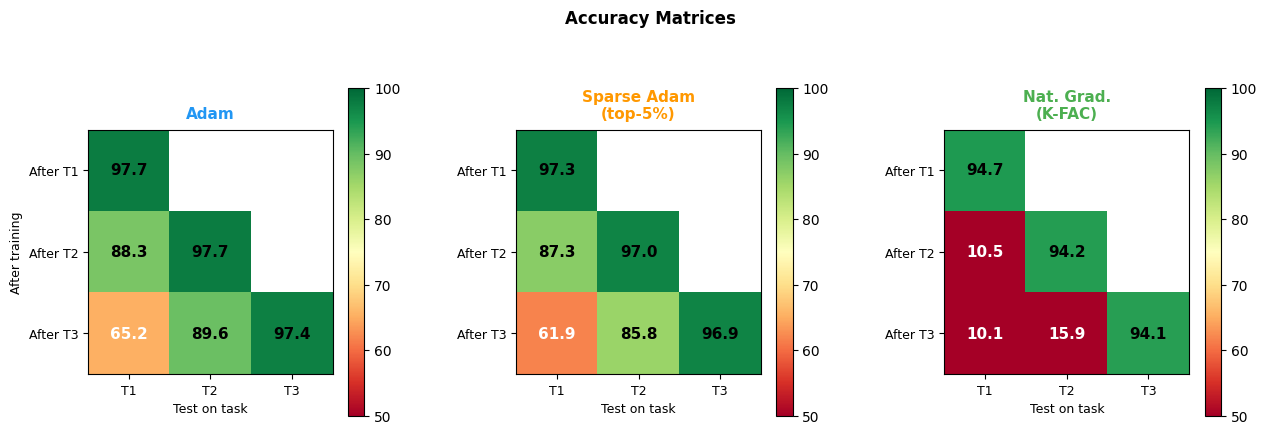

In [17]:
# =========================
# FIGURE 1: Accuracy heatmaps
# =========================
method_list = [
    ("Adam",                  acc_adam,   "#2196F3"),
    ("Sparse Adam\n(top-5%)", acc_sparse, "#FF9800"),
    ("Nat. Grad.\n(K-FAC)",   acc_ngd,    "#4CAF50"),
]

fig = plt.figure(figsize=(15, 5), facecolor='white')
gs  = gridspec.GridSpec(1, 3, wspace=0.40, figure=fig)

for col, (name, M, color) in enumerate(method_list):
    ax = fig.add_subplot(gs[0, col])
    masked = np.full_like(M, np.nan)

    for i in range(N_TASKS):
        for j in range(i+1):
            masked[i, j] = M[i, j]

    im = ax.imshow(masked, vmin=50, vmax=100, cmap='RdYlGn')

    for i in range(N_TASKS):
        for j in range(N_TASKS):
            if not np.isnan(masked[i, j]):
                ax.text(j, i, f"{masked[i,j]:.1f}",
                        ha='center', va='center', fontsize=11, fontweight='bold',
                        color='black' if masked[i,j] > 70 else 'white')

    ax.set_xticks(range(N_TASKS))
    ax.set_yticks(range(N_TASKS))
    ax.set_xticklabels([f"T{j+1}" for j in range(N_TASKS)], fontsize=9)
    ax.set_yticklabels([f"After T{i+1}" for i in range(N_TASKS)], fontsize=9)
    ax.set_xlabel("Test on task", fontsize=9)

    if col == 0:
        ax.set_ylabel("After training", fontsize=9)

    ax.set_title(name, fontsize=11, fontweight='bold', color=color, pad=8)
    plt.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle("Accuracy Matrices", fontsize=12, fontweight='bold')
plt.savefig('figure_accuracy_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


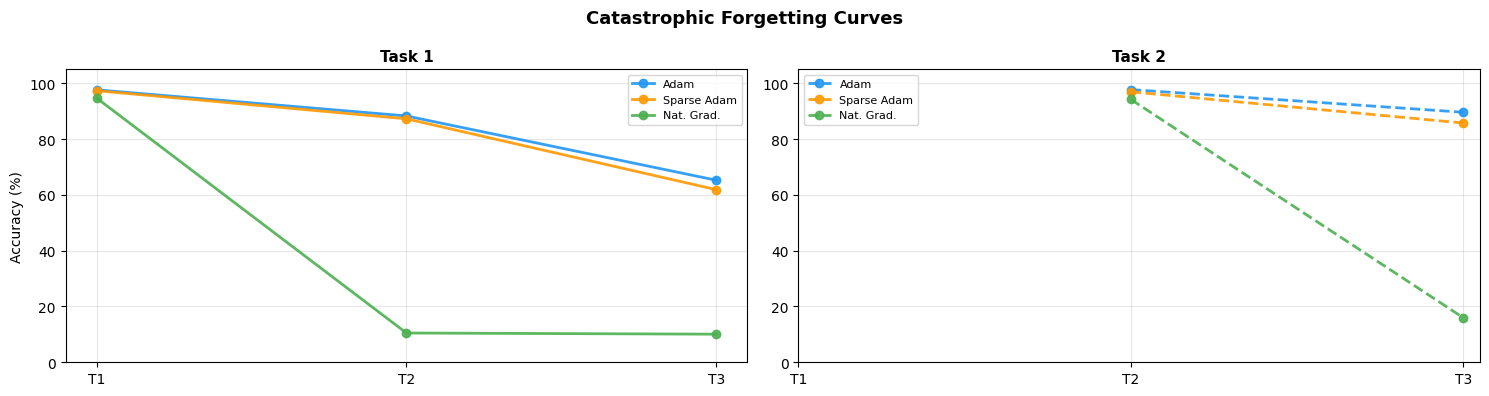

In [18]:
fig, axes = plt.subplots(1, N_TASKS-1, figsize=(15, 4), facecolor='white')

ls_styles = ['-', '--']

for j in range(N_TASKS - 1):
    ax = axes[j]

    for name, M, color in method_list:
        xs   = list(range(j+1, N_TASKS+1))
        accs = [M[i, j] for i in range(j, N_TASKS)]

        label = name.split(chr(10))[0]

        ax.plot(xs, accs,
                marker='o',
                color=color,
                linestyle=ls_styles[j % 2],
                linewidth=2,
                alpha=0.9,
                label=label)

    ax.set_xticks(range(1, N_TASKS+1))
    ax.set_xticklabels([f"T{i}" for i in range(1, N_TASKS+1)])
    ax.set_title(f"Task {j+1}", fontsize=11, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)

    if j == 0:
        ax.set_ylabel("Accuracy (%)")

    ax.legend(fontsize=8)

fig.suptitle("Catastrophic Forgetting Curves", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('figure_forgetting_curves_split.png', dpi=150, bbox_inches='tight')
plt.show()

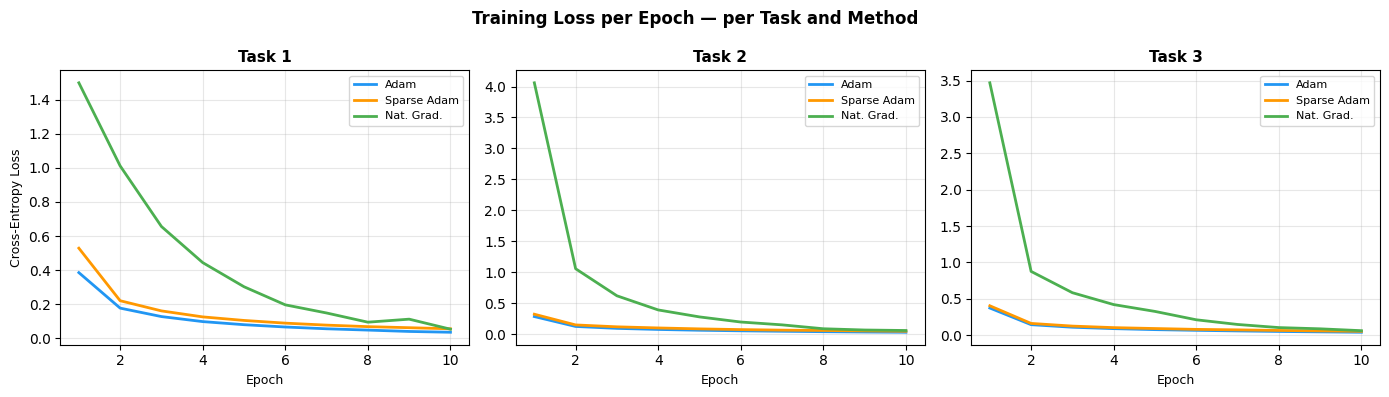

Figure 2 saved.


In [19]:
# ── Figure 2: Learning curves (loss over epochs, per task) ───────────────────
fig2, axes2 = plt.subplots(1, N_TASKS, figsize=(14, 4), facecolor='white')
fig2.suptitle("Training Loss per Epoch — per Task and Method",
              fontsize=12, fontweight='bold')

method_histories = [
    ("Adam",        hist_adam,   "#2196F3"),
    ("Sparse Adam", hist_sparse, "#FF9800"),
    ("Nat. Grad.",  hist_ngd,    "#4CAF50"),
]

for t_id in range(N_TASKS):
    ax = axes2[t_id]
    for name, hist, color in method_histories:
        # Filter history for this task
        epochs = [h[1] for h in hist if h[0] == t_id]
        losses = [h[2] for h in hist if h[0] == t_id]
        ax.plot(epochs, losses, color=color, linewidth=2,
                markersize=4, label=name)
    ax.set_title(f"Task {t_id+1}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=9)
    if t_id == 0:
        ax.set_ylabel("Cross-Entropy Loss", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure2_learning_curves.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 2 saved.")

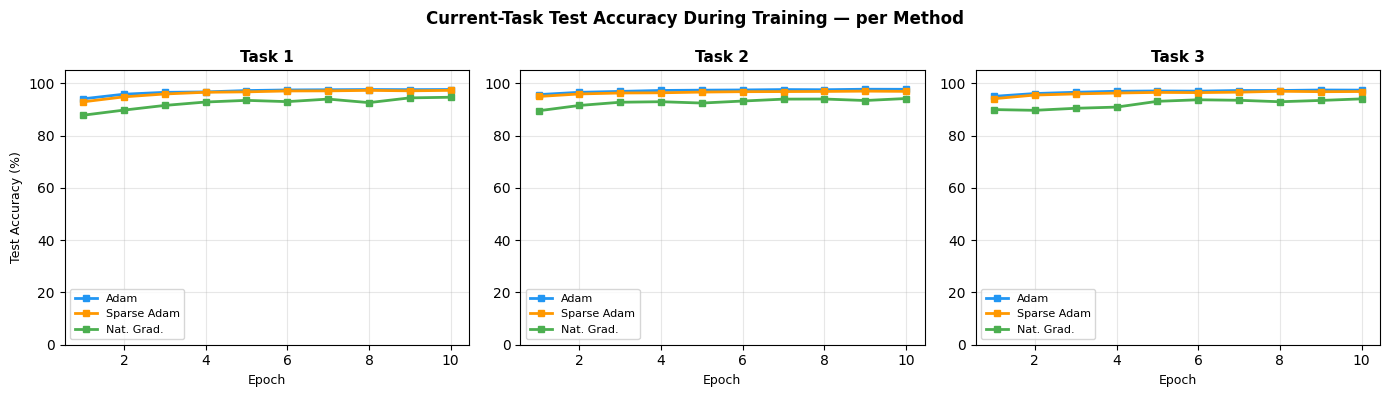

Figure 3 saved.


In [20]:
# Figure 3: Within-task accuracy trajectories during training
fig3, axes3 = plt.subplots(1, N_TASKS, figsize=(14, 4), facecolor='white')
fig3.suptitle("Current-Task Test Accuracy During Training — per Method",
              fontsize=12, fontweight='bold')

for t_id in range(N_TASKS):
    ax = axes3[t_id]
    for name, hist, color in method_histories:
        epochs = [h[1] for h in hist if h[0] == t_id]
        accs   = [h[3] for h in hist if h[0] == t_id]
        ax.plot(epochs, accs, color=color, linewidth=2, marker='s',
                markersize=4, label=name)
    ax.set_title(f"Task {t_id+1}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch", fontsize=9)
    if t_id == 0:
        ax.set_ylabel("Test Accuracy (%)", fontsize=9)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_accuracy_trajectories.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3 saved.")

## 10 · Ablations



### 10.1  Effect of sparsity fraction k on Sparse Adam

In [21]:
# Ablation: vary k_frac in Sparse Adam
k_fracs       = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
sparse_results = {}

for kf in k_fracs:
    print(f"  k_frac={kf:.2f}", end=' ... ', flush=True)
    torch.manual_seed(42)
    model_ab = MLP().to(DEVICE)
    opt_ab   = SparseAdam(model_ab.parameters(), lr=LR_SPARSE, k_frac=kf)

    acc_ab = np.full((N_TASKS, N_TASKS), np.nan)
    for task_id, task in enumerate(tasks):
        loader = make_loader(task, train=True)
        for _ in range(N_EPOCHS):
            train_epoch(model_ab, opt_ab, loader, method='sparse')
        for prev_id in range(task_id + 1):
            acc_ab[task_id, prev_id] = evaluate(model_ab, tasks[prev_id])

    sparse_results[kf] = acc_ab
    print(f"avg_final={avg_final_acc(acc_ab):.1f}%  forgetting={avg_forgetting(acc_ab):.1f}%")

print("\nAblation complete.")

  k_frac=0.01 ... avg_final=77.1%  forgetting=28.0%
  k_frac=0.05 ... avg_final=82.2%  forgetting=22.2%
  k_frac=0.10 ... avg_final=79.0%  forgetting=27.3%
  k_frac=0.25 ... avg_final=84.4%  forgetting=19.6%
  k_frac=0.50 ... avg_final=83.5%  forgetting=21.1%
  k_frac=1.00 ... avg_final=84.0%  forgetting=20.5%

Ablation complete.


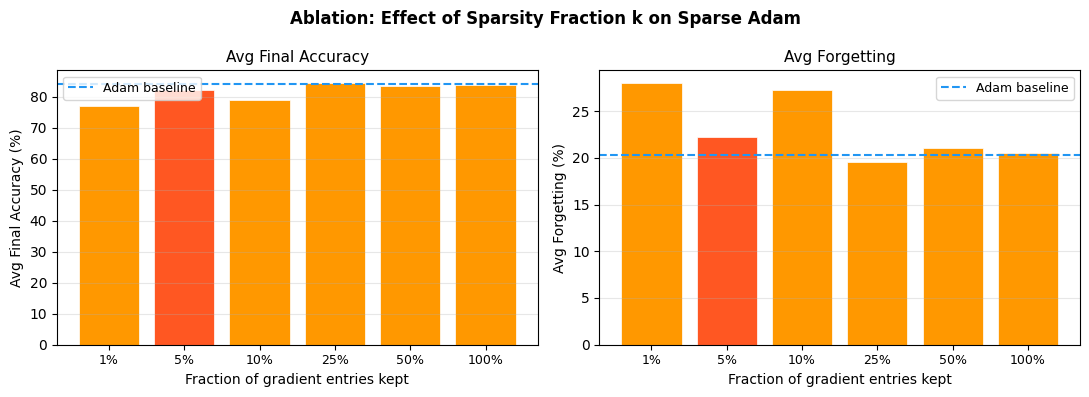

Figure 4 saved.


In [22]:
# Plot ablation results
fig4, (ax4a, ax4b) = plt.subplots(1, 2, figsize=(11, 4), facecolor='white')
fig4.suptitle("Ablation: Effect of Sparsity Fraction k on Sparse Adam",
              fontsize=12, fontweight='bold')

kf_labels   = [f"{int(k*100)}%" for k in k_fracs]
final_accs  = [avg_final_acc(sparse_results[k])  for k in k_fracs]
forgettings = [avg_forgetting(sparse_results[k]) for k in k_fracs]

# Mark the default k=5%
colors_ab = ['#FF5722' if k == K_FRAC else '#FF9800' for k in k_fracs]

ax4a.bar(kf_labels, final_accs, color=colors_ab, edgecolor='white', linewidth=0.5)
ax4a.set_xlabel("Fraction of gradient entries kept", fontsize=10)
ax4a.set_ylabel("Avg Final Accuracy (%)", fontsize=10)
ax4a.set_title("Avg Final Accuracy", fontsize=11)
ax4a.grid(True, alpha=0.3, axis='y')
ax4a.axhline(avg_final_acc(acc_adam), color='#2196F3', linestyle='--',
             linewidth=1.5, label='Adam baseline')
ax4a.legend(fontsize=9)

ax4b.bar(kf_labels, forgettings, color=colors_ab, edgecolor='white', linewidth=0.5)
ax4b.set_xlabel("Fraction of gradient entries kept", fontsize=10)
ax4b.set_ylabel("Avg Forgetting (%)", fontsize=10)
ax4b.set_title("Avg Forgetting", fontsize=11)
ax4b.grid(True, alpha=0.3, axis='y')
ax4b.axhline(avg_forgetting(acc_adam), color='#2196F3', linestyle='--',
             linewidth=1.5, label='Adam baseline')
ax4b.legend(fontsize=9)

for ax in (ax4a, ax4b):
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('figure4_sparsity_ablation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4 saved.")

### 10.2  Effect of NGD learning rate and damping

In [23]:
# Ablation: NGD damping sweep
# dampings    = [1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1]
dampings    = [ 1e-1, 5e-1, 9e-1]
ngd_results = {}

for dam in dampings:
    print(f"  damping={dam:.0e}", end=' ... ', flush=True)
    torch.manual_seed(42)
    model_ab = MLP().to(DEVICE)
    opt_ab   = NaturalGradientSGD(model_ab, lr=LR_NGD, damping=dam)

    acc_ab = np.full((N_TASKS, N_TASKS), np.nan)
    for task_id, task in enumerate(tasks):
        loader = make_loader(task, train=True)
        for _ in range(N_EPOCHS):
            train_epoch(model_ab, opt_ab, loader, method='ngd')
        for prev_id in range(task_id + 1):
            acc_ab[task_id, prev_id] = evaluate(model_ab, tasks[prev_id])

    ngd_results[dam] = acc_ab
    print(f"avg_final={avg_final_acc(acc_ab):.1f}%  forgetting={avg_forgetting(acc_ab):.1f}%")

print("\nNGD ablation complete.")

  damping=1e-01 ... avg_final=50.1%  forgetting=70.2%
  damping=5e-01 ... avg_final=74.3%  forgetting=34.0%
  damping=9e-01 ... avg_final=81.2%  forgetting=22.1%

NGD ablation complete.


In [24]:
# Ablation: NGD damping sweep
# dampings    = [1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1]
dampings    = [ 1e-1, 5e-1, 9e-1]
ngd_results = {}

for dam in dampings:
    print(f"  damping={dam:.0e}", end=' ... ', flush=True)
    torch.manual_seed(42)
    model_ab = MLP().to(DEVICE)
    opt_ab   = NaturalGradientSGD(model_ab, lr=LR_NGD, damping=dam)

    acc_ab = np.full((N_TASKS, N_TASKS), np.nan)
    for task_id, task in enumerate(tasks):
        loader = make_loader(task, train=True)
        for _ in range(N_EPOCHS):
            train_epoch(model_ab, opt_ab, loader, method='ngd')
        for prev_id in range(task_id + 1):
            acc_ab[task_id, prev_id] = evaluate(model_ab, tasks[prev_id])

    ngd_results[dam] = acc_ab
    print(f"avg_final={avg_final_acc(acc_ab):.1f}%  forgetting={avg_forgetting(acc_ab):.1f}%")

print("\nNGD ablation complete.")

  damping=1e-01 ... avg_final=50.1%  forgetting=70.2%
  damping=5e-01 ... avg_final=74.3%  forgetting=34.0%
  damping=9e-01 ... avg_final=81.2%  forgetting=22.1%

NGD ablation complete.


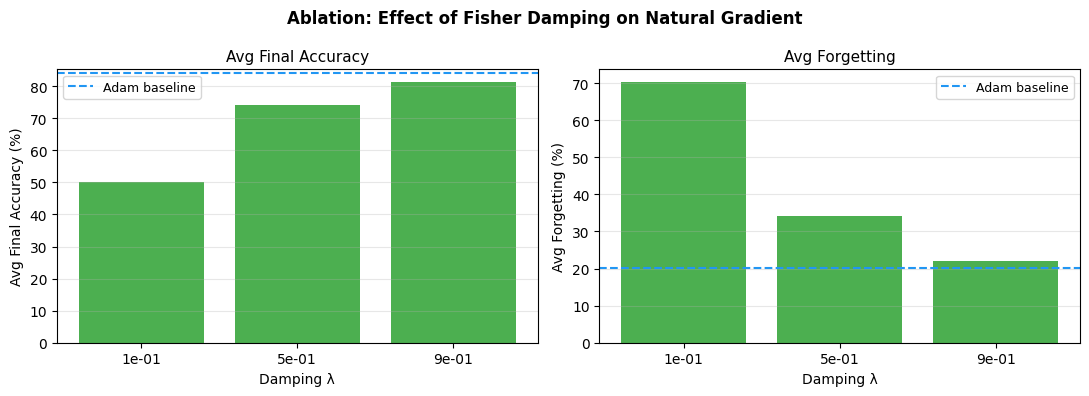

Figure 5 saved.


In [25]:
fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(11, 4), facecolor='white')
fig5.suptitle("Ablation: Effect of Fisher Damping on Natural Gradient",
              fontsize=12, fontweight='bold')

dam_labels  = [f"{d:.0e}" for d in dampings]
ngd_finals  = [avg_final_acc(ngd_results[d])  for d in dampings]
ngd_forg    = [avg_forgetting(ngd_results[d]) for d in dampings]
colors_dam  = ['#1B5E20' if d == NGD_DAMPING else '#4CAF50' for d in dampings]

ax5a.bar(dam_labels, ngd_finals, color=colors_dam)
ax5a.set_xlabel("Damping λ", fontsize=10)
ax5a.set_ylabel("Avg Final Accuracy (%)", fontsize=10)
ax5a.set_title("Avg Final Accuracy", fontsize=11)
ax5a.grid(True, alpha=0.3, axis='y')
ax5a.axhline(avg_final_acc(acc_adam), color='#2196F3', linestyle='--',
             linewidth=1.5, label='Adam baseline')
ax5a.legend(fontsize=9)

ax5b.bar(dam_labels, ngd_forg, color=colors_dam)
ax5b.set_xlabel("Damping λ", fontsize=10)
ax5b.set_ylabel("Avg Forgetting (%)", fontsize=10)
ax5b.set_title("Avg Forgetting", fontsize=11)
ax5b.grid(True, alpha=0.3, axis='y')
ax5b.axhline(avg_forgetting(acc_adam), color='#2196F3', linestyle='--',
             linewidth=1.5, label='Adam baseline')
ax5b.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figure5_damping_ablation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5 saved.")